In [1]:
import torch
import os
import pickle
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
is_developing = True

# Enable autoreload extension for Jupyter notebook
# This allows changes in imported modules to be reloaded automatically
if is_developing is True:
    %load_ext autoreload
    %autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42

In [3]:
def load_model(checkpoint_path, device):
    model = torch.load(checkpoint_path)
    model.to(device)
    model.eval()
    return model

def minmax_normalization(edge_weights):
    return np.array((edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min()))

def create_graph(edges, edge_weights, node_to_plot=0, plot_type="all", normalization_method="minmax"):
    if plot_type == "single":
        edge_index = np.where((edges[0, :] == node_to_plot) | (edges[1, :] == node_to_plot))[0]
        edges = edges[:, edge_index]
        edge_weights = edge_weights[edge_index].flatten()
    elif plot_type == "all":
        G = nx.Graph()
        G.add_edges_from(edges.T)
        neighbors = list(G.neighbors(node_to_plot))
        subgraph_nodes = [node_to_plot] + neighbors
        subgraph = G.subgraph(subgraph_nodes)
        edges = np.array(subgraph.edges()).T
        edge_weights = edge_weights.flatten()
    else:
        raise ValueError("Invalid plot type. Please choose 'single' or 'all'.")

    # Normalize edge weights to be in the range [0, 1] for color mapping
    if normalization_method == "minmax":
        edge_weights_normalized = minmax_normalization(edge_weights)
    else:
        raise ValueError("Invalid normalization method. Please choose 'minmax'.")
    edge_cmap = plt.cm.Blues
    edge_colors = [edge_cmap(weight) for weight in edge_weights_normalized]  # Convert to RGBA tuples
    G = nx.Graph()
    G.add_edges_from(edges.T)

    # Create the plot with edge weights
    pos = nx.spring_layout(G, seed=42)  # Fix the layout by setting a seed
    fig, ax = plt.subplots()
    nx.draw(G, pos, with_labels=True, node_color='lightblue', width=edge_weights_normalized, edge_color=edge_colors, ax=ax)
    plt.title(f'Node {node_to_plot} and its Adjacent Edges')
    plt.axis('off')

    sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=plt.Normalize(vmin=edge_weights_normalized.min(), vmax=edge_weights_normalized.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Edge Weight')  # Provide the ax argument

    return fig 

In [4]:
model_type_dir = "different_Cij_Ni"
config_dir = f"./config/{model_type_dir}"
for config_file in os.listdir(config_dir):
    config_path = os.path.join(config_dir, config_file)
    with open(config_path, 'r') as f:
        config = json.load(f)
    if config["layer_type"] == "GATConv":
        break
config_name = os.path.basename(config_path)
print(config_path, config_name)

./config/different_Cij_Ni\4.json 4.json


In [5]:
texture = "comp_rot_z-45"
data_dirname = f"{model_type_dir}"
data_dir = f"./graph_data/{data_dirname}"
data_filepath = os.path.join(data_dir, f"{texture}.pkl")
# target_scaler_path = f"./graph_data/{data_dirname}/target_scaler.pickle"
model_path = f"./output/{model_type_dir}/models/config_{config_name}_checkpoint.pth"

In [6]:
model = load_model(model_path, device)
with open(data_filepath, 'rb') as f:
    data = pickle.load(f)
for i in data:
    i.return_attention_weights = True
# with open(target_scaler_path, 'rb') as f:
#     target_scaler = pickle.load(f)

C:\Users\Tansu\AppData\Local\Temp\ipykernel_45388\3784699332.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(checkpoint_path)


In [7]:
original_indices = list(range(len(data)))
train_data, temp_data, train_indices, temp_indices = train_test_split(
    data, original_indices, test_size=0.3, random_state=seed, shuffle=True
)
train_loader = DataLoader(train_data, batch_size=config["batch_size"], shuffle=False)
train_loader = DataLoader(train_data, batch_size=1, shuffle=False)

n_epoch = config["n_epoch"]

for batch_idx, batch in enumerate(train_loader):
    batch = batch.to(device)
    print(batch.edge_index.shape)
    break
preds = model(batch)
trues = batch.y

torch.Size([2, 16798])


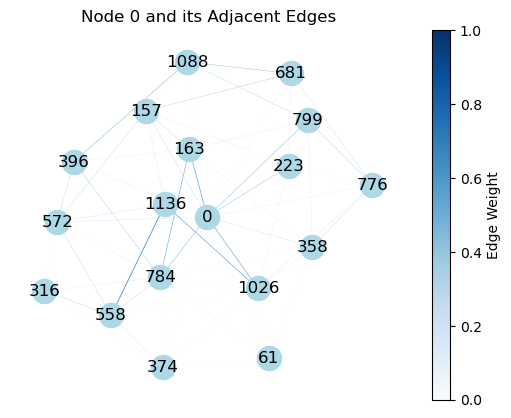

In [8]:
edges_np = batch.edge_index.detach().cpu().numpy()
attention_weights = batch.edge_weight.detach().cpu().numpy().reshape(-1, 1)
# scaler = StandardScaler()
# attention_weights = scaler.fit_transform(attention_weights)
fig = create_graph(edges_np, attention_weights)
plt.show(fig)

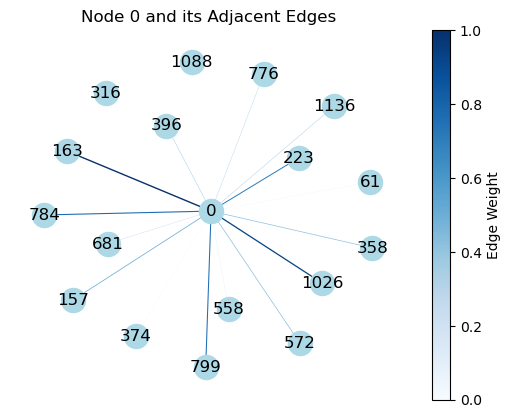

In [9]:
fig = create_graph(edges_np, attention_weights, node_to_plot=0, plot_type="single")
plt.show(fig)

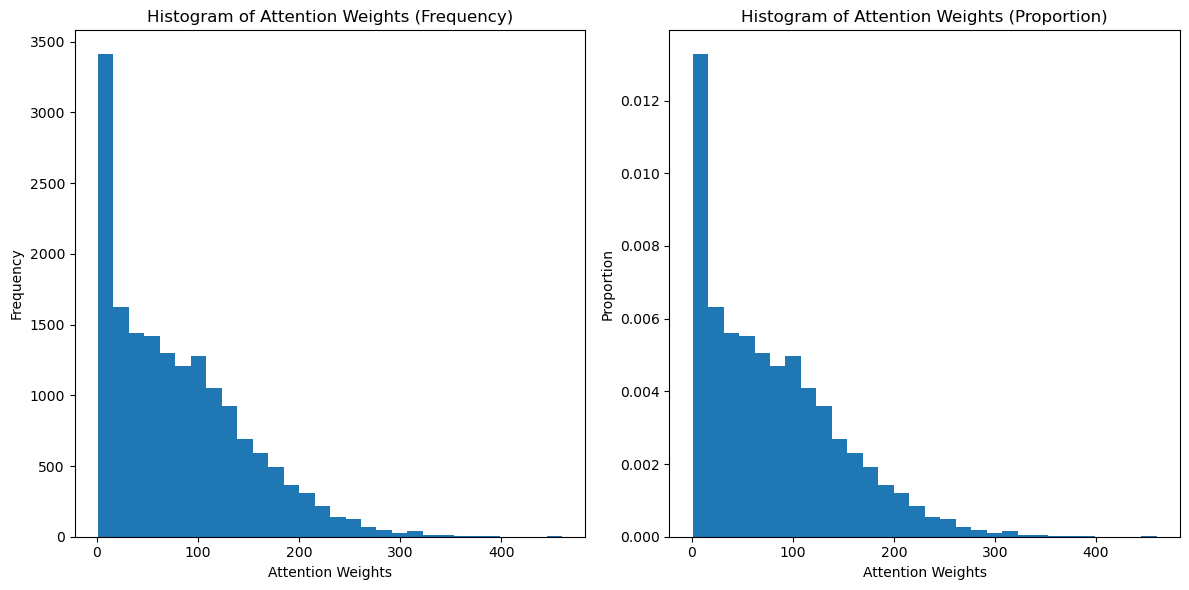

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Frequency histogram
ax1.hist(attention_weights, bins=30)
ax1.set_xlabel('Attention Weights')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Attention Weights (Frequency)')

# Proportion histogram
ax2.hist(attention_weights, bins=30, density=True)
ax2.set_xlabel('Attention Weights')
ax2.set_ylabel('Proportion')
ax2.set_title('Histogram of Attention Weights (Proportion)')

plt.tight_layout()
plt.show()

In [11]:
output_dir = f"./output/{model_type_dir}/attention_weights"
os.makedirs(output_dir, exist_ok=True)

In [19]:
import pandas as pd

In [29]:
df = pd.DataFrame({'node_1': edges_np[0], 'node_2': edges_np[1], 'attention_weights': attention_weights.flatten()})
df.sort_values(by='attention_weights', ascending=False, inplace=True)
df.to_csv(os.path.join(output_dir, f"attention_weights.csv"), index=False)

In [28]:
output_dir

'./output/different_Cij_Ni/attention_weights'

(2, 16798)

In [17]:
attention_weights.shape

(16798, 1)

In [12]:
p = 80
threshold = np.percentile(attention_weights, p)
top_indices = np.where(attention_weights >= threshold)[0]
top_edges = edges_np[:, top_indices]
top_edges_filepath = os.path.join(output_dir, f"top_{100-p}_percent_edges.npy")
np.save(top_edges_filepath, top_edges)